# 6. Frontera Eficiente, CML y SML

En esta sección veremos como la inserción de un activo libre de riesgo puede mejorar las condiciones del portafolio de mínima varianza con respecto a la rentabilidad, y el de maxima rentabilidad con respecto al riesgo. Ver diapositivas [(descargar_diapositivas)](4_Modelo_CAPM-SML.pdf)

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

# ─── Configuración ───
tickers = ["AAPL", "JNJ", "JPM", "XOM", "PG"]
benchmark = "^GSPC"
inicio = "2022-01-01"
fin = "2026-01-01"
rf_anual = 0.05                    # Tasa libre de riesgo anual (5%)
rf_diario = (1 + rf_anual) ** (1/252) - 1  # Tasa diaria equivalente

# ─── Descargar datos ───
todos = tickers + [benchmark]
datos = yf.download(todos, start=inicio, end=fin)["Close"]
datos.columns = [t if t != benchmark else "SP500" for t in datos.columns]

# ─── Rendimientos logarítmicos diarios ───
rendimientos = np.log(datos / datos.shift(1)).dropna()



print(f"Período: {inicio} a {fin}")
print(f"Activos: {tickers}")
print(f"Tasa libre de riesgo: {rf_anual:.0%} anual ({rf_diario:.6f} diaria)")
print(f"Observaciones: {len(rendimientos)} días")

[*********************100%***********************]  6 of 6 completed

Período: 2022-01-01 a 2026-01-01
Activos: ['AAPL', 'JNJ', 'JPM', 'XOM', 'PG']
Tasa libre de riesgo: 5% anual (0.000194 diaria)
Observaciones: 1002 días


## 1. Frontera Eficiente 

Construimos la **frontera eficiente de Markowitz** a partir de los rendimientos históricos de las 5 acciones.

- Estimamos la **media** y la **matriz de covarianza** de los rendimientos.
- Usamos `PyPortfolioOpt` para resolver los problemas de optimización.
- Identificamos dos portafolios clave:
  - **Mínima varianza global**: el portafolio con menor riesgo posible.
  - **Máximo Sharpe (tangente)**: el portafolio con mayor rendimiento ajustado por riesgo.

In [4]:
from pypfopt import expected_returns, risk_models, EfficientFrontier

# ─── Solo acciones (sin benchmark) ───
activos = rendimientos.drop(columns="SP500")

# ─── Rendimiento esperado anualizado y matriz de covarianza ───
mu = expected_returns.mean_historical_return(datos.drop(columns="SP500"), frequency=252)
S  = risk_models.sample_cov(datos.drop(columns="SP500"), frequency=252)

print("Rendimiento esperado anualizado:")
print(mu.round(4))
print("\nMatriz de covarianza (anualizada):")
print(S.round(4))

Rendimiento esperado anualizado:
AAPL    0.1120
JNJ     0.0797
JPM     0.2212
PG     -0.0070
XOM     0.2169
dtype: float64

Matriz de covarianza (anualizada):
        AAPL     JNJ     JPM      PG     XOM
AAPL  0.0814  0.0076  0.0281  0.0138  0.0166
JNJ   0.0076  0.0298  0.0093  0.0135  0.0060
JPM   0.0281  0.0093  0.0622  0.0087  0.0204
PG    0.0138  0.0135  0.0087  0.0321  0.0038
XOM   0.0166  0.0060  0.0204  0.0038  0.0693


### 1.1 Portafolio de Mínima Varianza Global

Es el portafolio que minimiza la varianza total, sin importar el rendimiento.
$$\min_w \; w^\top \Sigma \, w \quad \text{s.a.} \quad \sum w_i = 1, \; w_i \geq 0$$

In [5]:
# ─── Portafolio de Mínima Varianza ───
ef_min = EfficientFrontier(mu, S)
ef_min.min_volatility()
w_min = ef_min.clean_weights()
ret_min, vol_min, _ = ef_min.portfolio_performance(verbose=False)

print("══════ PORTAFOLIO DE MÍNIMA VARIANZA ══════")
print(f"Rendimiento anual: {ret_min:.4%}")
print(f"Volatilidad anual: {vol_min:.4%}")
print(f"\nPesos:")
for ticker, peso in w_min.items():
    if peso > 0:
        print(f"  {ticker}: {peso:.4%}")

══════ PORTAFOLIO DE MÍNIMA VARIANZA ══════
Rendimiento anual: 9.0277%
Volatilidad anual: 13.1982%

Pesos:
  AAPL: 5.8440%
  JNJ: 36.2100%
  JPM: 10.3030%
  PG: 31.8240%
  XOM: 15.8200%


### 1.2 Portafolio Tangente (Máximo Sharpe)

Es el portafolio que maximiza el **ratio de Sharpe**, es decir, el exceso de rendimiento por unidad de riesgo:

$$\max_w \; \frac{w^\top \mu - r_f}{\sqrt{w^\top \Sigma \, w}} \quad \text{s.a.} \quad \sum w_i = 1, \; w_i \geq 0$$

Este portafolio es el punto de **tangencia** entre la frontera eficiente y la Línea del Mercado de Capitales (CML).

In [6]:
# ─── Portafolio Tangente (Máximo Sharpe) ───
ef_sharpe = EfficientFrontier(mu, S)
ef_sharpe.max_sharpe(risk_free_rate=rf_anual)
w_sharpe = ef_sharpe.clean_weights()
ret_sharpe, vol_sharpe, sharpe_ratio = ef_sharpe.portfolio_performance(
    verbose=False, risk_free_rate=rf_anual
)

print("══════ PORTAFOLIO TANGENTE (MÁX. SHARPE) ══════")
print(f"Rendimiento anual: {ret_sharpe:.4%}")
print(f"Volatilidad anual: {vol_sharpe:.4%}")
print(f"Ratio de Sharpe:   {sharpe_ratio:.4f}")
print(f"\nPesos:")
for ticker, peso in w_sharpe.items():
    if peso > 0:
        print(f"  {ticker}: {peso:.4%}")

══════ PORTAFOLIO TANGENTE (MÁX. SHARPE) ══════
Rendimiento anual: 21.9274%
Volatilidad anual: 20.7272%
Ratio de Sharpe:   0.8167

Pesos:
  JPM: 55.0510%
  XOM: 44.9490%


## 2. Frontera Eficiente y Línea del Mercado de Capitales (CML)

La **CML** (Capital Market Line) conecta el activo libre de riesgo ($r_f$) con el **portafolio tangente** y representa las mejores combinaciones posibles entre riesgo y rendimiento:

$$E(R_p) = r_f + \frac{E(R_T) - r_f}{\sigma_T} \cdot \sigma_p$$

donde:
- $r_f = 5\%$ es la tasa libre de riesgo  
- $(E(R_T), \sigma_T)$ son el rendimiento y volatilidad del portafolio tangente
- La pendiente $\frac{E(R_T) - r_f}{\sigma_T}$ es el **Ratio de Sharpe** del portafolio tangente

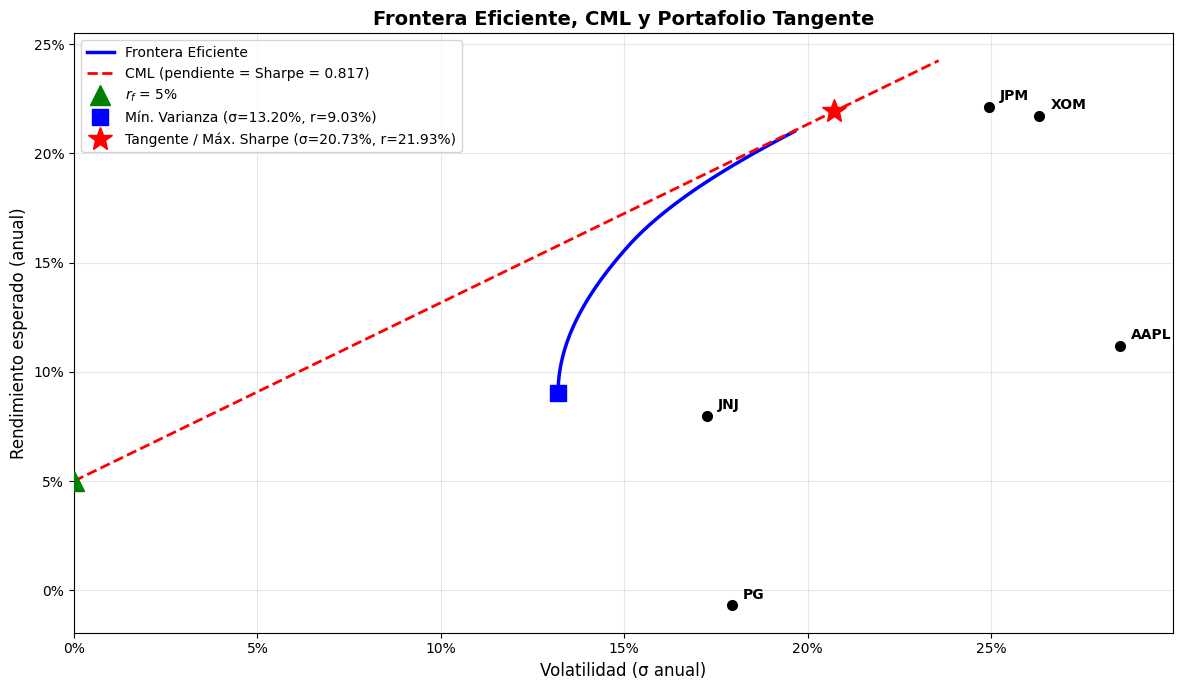

In [8]:
# ─── Generar puntos de la frontera eficiente ───
n_puntos = 100
volatilidades_ef = []
rendimientos_ef = []

# Rango de rendimientos objetivo entre mín varianza y algo por encima del máximo
ret_objetivo = np.linspace(ret_min, mu.max() * 0.95, n_puntos)

for target in ret_objetivo:
    try:
        ef_temp = EfficientFrontier(mu, S)
        ef_temp.efficient_return(target_return=target)
        r, v, _ = ef_temp.portfolio_performance(verbose=False)
        rendimientos_ef.append(r)
        volatilidades_ef.append(v)
    except Exception:
        continue

volatilidades_ef = np.array(volatilidades_ef)
rendimientos_ef = np.array(rendimientos_ef)

# ─── Línea del Mercado de Capitales (CML) ───
sigma_cml = np.linspace(0, max(volatilidades_ef) * 1.2, 100)
ret_cml = rf_anual + sharpe_ratio * sigma_cml

# ─── Gráfico ───
fig, ax = plt.subplots(figsize=(12, 7))

# Frontera eficiente
ax.plot(volatilidades_ef, rendimientos_ef, "b-", linewidth=2.5, label="Frontera Eficiente")

# CML
ax.plot(sigma_cml, ret_cml, "r--", linewidth=2, label=f"CML (pendiente = Sharpe = {sharpe_ratio:.3f})")

# Activo libre de riesgo
ax.plot(0, rf_anual, "g^", markersize=14, zorder=5, label=f"$r_f$ = {rf_anual:.0%}")

# Portafolio de mínima varianza
ax.plot(vol_min, ret_min, "bs", markersize=12, zorder=5,
        label=f"Mín. Varianza (σ={vol_min:.2%}, r={ret_min:.2%})")

# Portafolio tangente
ax.plot(vol_sharpe, ret_sharpe, "r*", markersize=18, zorder=5,
        label=f"Tangente / Máx. Sharpe (σ={vol_sharpe:.2%}, r={ret_sharpe:.2%})")

# Activos individuales
for ticker in tickers:
    r_i = mu[ticker]
    v_i = np.sqrt(S.loc[ticker, ticker])
    ax.plot(v_i, r_i, "ko", markersize=7, zorder=4)
    ax.annotate(ticker, (v_i, r_i), textcoords="offset points",
                xytext=(8, 5), fontsize=10, fontweight="bold")

ax.set_xlabel("Volatilidad (σ anual)", fontsize=12)
ax.set_ylabel("Rendimiento esperado (anual)", fontsize=12)
ax.set_title("Frontera Eficiente, CML y Portafolio Tangente", fontsize=14, fontweight="bold")
ax.legend(loc="upper left", fontsize=10, frameon=True)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.grid(True, alpha=0.3)
ax.set_xlim(left=0)
plt.tight_layout()
plt.show()

## 3. Combinaciones sobre la CML: Activo Libre de Riesgo + Portafolio Tangente

Un inversor puede **combinar** el activo libre de riesgo con el portafolio tangente para ubicarse en cualquier punto de la CML:

| Peso en $r_f$ ($1-w$) | Peso en Tangente ($w$) | Estrategia |
|:---:|:---:|:---|
| 100% | 0% | Todo en activo libre de riesgo |
| 50% | 50% | Moderado / conservador |
| 0% | 100% | 100% portafolio tangente |
| < 0% | > 100% | **Apalancamiento** (pedir prestado a $r_f$ e invertir más en el tangente) |

$$E(R_c) = (1-w) \cdot r_f + w \cdot E(R_T)$$
$$\sigma_c = w \cdot \sigma_T$$

In [9]:
# ─── Tabla de combinaciones CML ───
pesos_tangente = np.arange(0, 1.51, 0.10)  # de 0% a 150% (incluye apalancamiento)

tabla_cml = pd.DataFrame({
    "w (Tangente)":   pesos_tangente,
    "1-w (Rf)":       1 - pesos_tangente,
    "E(Rc) anual":    (1 - pesos_tangente) * rf_anual + pesos_tangente * ret_sharpe,
    "σ(Rc) anual":    pesos_tangente * vol_sharpe,
})
tabla_cml["Sharpe"] = (tabla_cml["E(Rc) anual"] - rf_anual) / tabla_cml["σ(Rc) anual"]
tabla_cml.loc[tabla_cml["σ(Rc) anual"] == 0, "Sharpe"] = np.nan  # evitar div/0

# Formato para impresión
tabla_display = tabla_cml.copy()
tabla_display["w (Tangente)"] = tabla_display["w (Tangente)"].map("{:.0%}".format)
tabla_display["1-w (Rf)"]     = tabla_display["1-w (Rf)"].map("{:.0%}".format)
tabla_display["E(Rc) anual"]  = tabla_display["E(Rc) anual"].map("{:.2%}".format)
tabla_display["σ(Rc) anual"]  = tabla_display["σ(Rc) anual"].map("{:.2%}".format)
tabla_display["Sharpe"]       = tabla_display["Sharpe"].map(lambda x: f"{x:.4f}" if pd.notna(x) else "—")
tabla_display.index = range(1, len(tabla_display) + 1)
tabla_display.index.name = "#"

print("══════ COMBINACIONES SOBRE LA CML ══════\n")
print(tabla_display.to_string())

══════ COMBINACIONES SOBRE LA CML ══════

   w (Tangente) 1-w (Rf) E(Rc) anual σ(Rc) anual  Sharpe
#                                                       
1            0%     100%       5.00%       0.00%       —
2           10%      90%       6.69%       2.07%  0.8167
3           20%      80%       8.39%       4.15%  0.8167
4           30%      70%      10.08%       6.22%  0.8167
5           40%      60%      11.77%       8.29%  0.8167
6           50%      50%      13.46%      10.36%  0.8167
7           60%      40%      15.16%      12.44%  0.8167
8           70%      30%      16.85%      14.51%  0.8167
9           80%      20%      18.54%      16.58%  0.8167
10          90%      10%      20.23%      18.65%  0.8167
11         100%       0%      21.93%      20.73%  0.8167
12         110%     -10%      23.62%      22.80%  0.8167
13         120%     -20%      25.31%      24.87%  0.8167
14         130%     -30%      27.01%      26.95%  0.8167
15         140%     -40%      28.70%      29.0

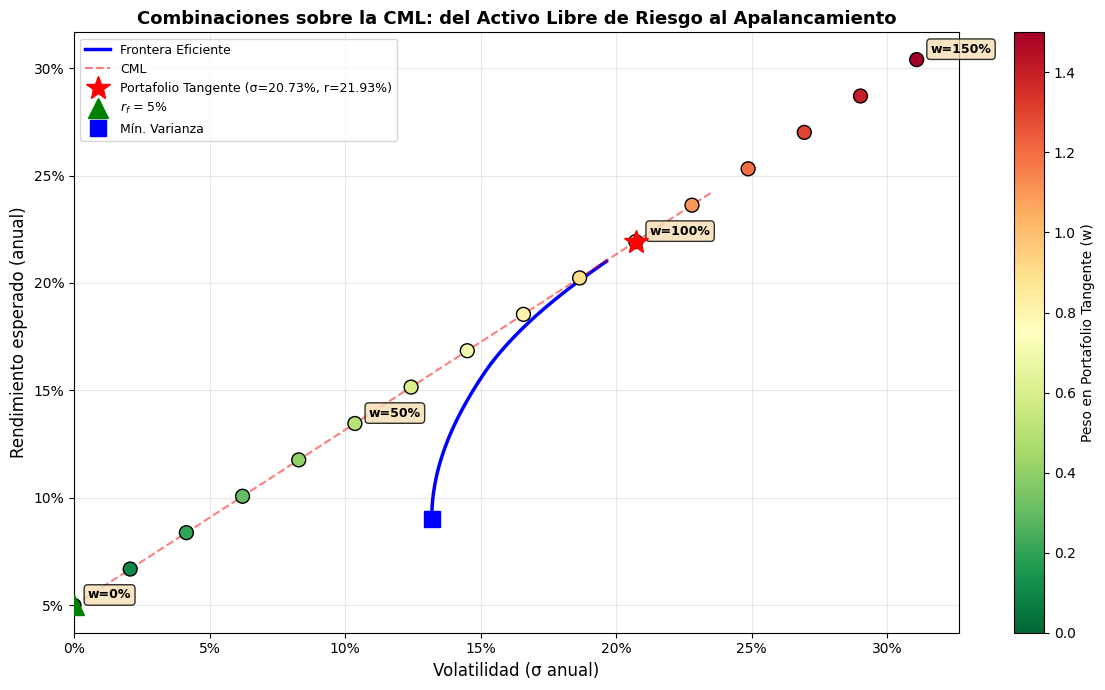

In [10]:
# ─── Visualización de las combinaciones sobre la CML ───
fig, ax = plt.subplots(figsize=(12, 7))

# Frontera eficiente
ax.plot(volatilidades_ef, rendimientos_ef, "b-", linewidth=2.5, label="Frontera Eficiente")

# CML completa
ax.plot(sigma_cml, ret_cml, "r--", linewidth=1.5, alpha=0.5, label="CML")

# Puntos de las combinaciones de la tabla
ret_combinaciones = (1 - pesos_tangente) * rf_anual + pesos_tangente * ret_sharpe
vol_combinaciones = pesos_tangente * vol_sharpe
scatter = ax.scatter(vol_combinaciones, ret_combinaciones, c=pesos_tangente,
                     cmap="RdYlGn_r", s=100, edgecolors="black", zorder=5)
plt.colorbar(scatter, ax=ax, label="Peso en Portafolio Tangente (w)")

# Etiquetar algunos puntos clave
for i, w in enumerate(pesos_tangente):
    if w in [0, 0.5, 1.0, 1.5]:
        ax.annotate(f"w={w:.0%}",
                    (vol_combinaciones[i], ret_combinaciones[i]),
                    textcoords="offset points", xytext=(10, 5), fontsize=9,
                    fontweight="bold",
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="wheat", alpha=0.8))

# Portafolio tangente
ax.plot(vol_sharpe, ret_sharpe, "r*", markersize=18, zorder=6,
        label=f"Portafolio Tangente (σ={vol_sharpe:.2%}, r={ret_sharpe:.2%})")

# Activo libre de riesgo
ax.plot(0, rf_anual, "g^", markersize=14, zorder=6, label=f"$r_f$ = {rf_anual:.0%}")

# Portafolio mínima varianza
ax.plot(vol_min, ret_min, "bs", markersize=12, zorder=6, label="Mín. Varianza")

ax.set_xlabel("Volatilidad (σ anual)", fontsize=12)
ax.set_ylabel("Rendimiento esperado (anual)", fontsize=12)
ax.set_title("Combinaciones sobre la CML: del Activo Libre de Riesgo al Apalancamiento",
             fontsize=13, fontweight="bold")
ax.legend(loc="upper left", fontsize=9, frameon=True)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.grid(True, alpha=0.3)
ax.set_xlim(left=0)
plt.tight_layout()
plt.show()

### Combinación óptima: mismo riesgo que Mín. Varianza, mayor rendimiento

¿Qué pasa si buscamos en la CML el punto que tiene **la misma volatilidad** que el portafolio de mínima varianza?  
Al combinar $r_f$ con el portafolio tangente en la proporción exacta, obtenemos un portafolio que **domina** al de mínima varianza: mismo riesgo, pero mayor rendimiento gracias a la diversificación con el activo libre de riesgo.

══════ MEJOR DIVERSIFICACIÓN: Rf + Tangente ══════

  Peso en activo libre de riesgo (1-w): 36.32%
  Peso en portafolio tangente    (w):   63.68%

  → Volatilidad resultante:  13.1982%
  → Rendimiento resultante:  15.7786%

── Comparación con Mínima Varianza pura ──
  Mín. Varianza:  σ = 13.1982%  |  E(R) = 9.0277%
  CML óptima:     σ = 13.1982%  |  E(R) = 15.7786%

  ✓ Ganancia en rendimiento: +6.7509% (mismo riesgo)

── Pesos finales por activo ──
  Activo libre de riesgo    36.32%
  JPM                       35.05%
  XOM                       28.62%


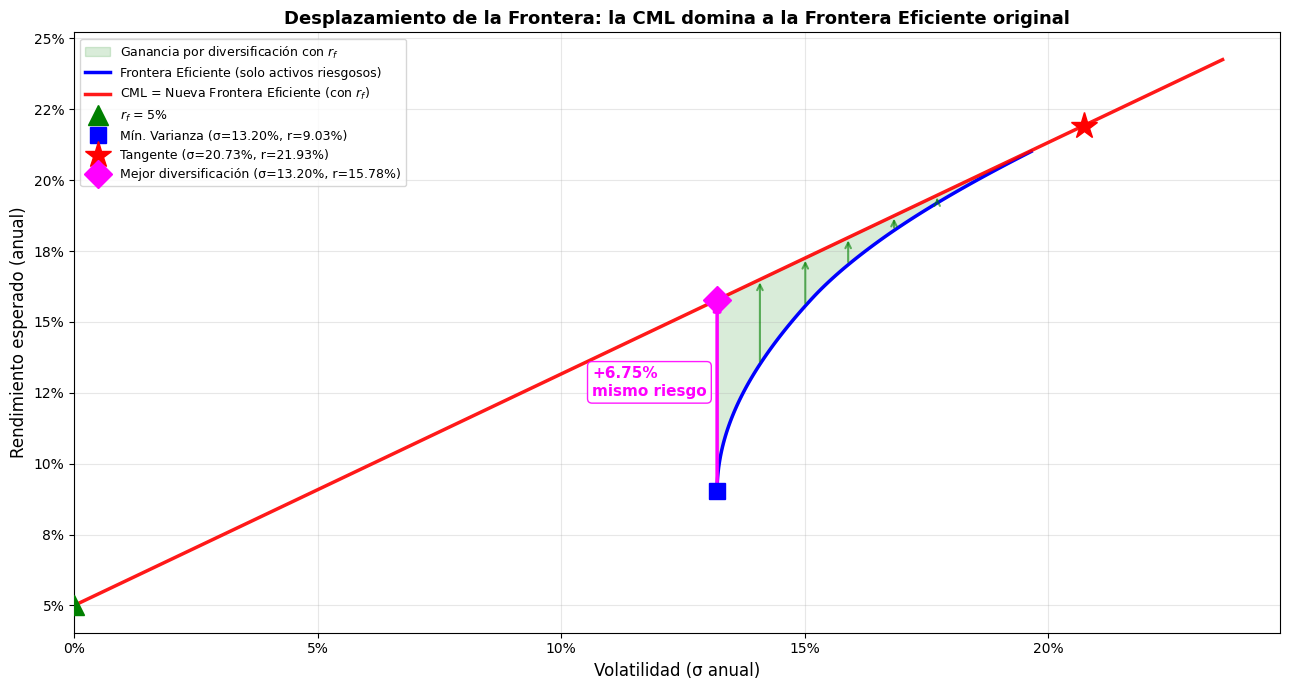

In [12]:
# ─── Combinación CML que iguala el riesgo del portafolio de mínima varianza ───
# σ_c = w * σ_T  →  w* = σ_min / σ_T
w_optimo = vol_min / vol_sharpe
ret_optimo = (1 - w_optimo) * rf_anual + w_optimo * ret_sharpe
vol_optimo = w_optimo * vol_sharpe  # = vol_min

print("══════ MEJOR DIVERSIFICACIÓN: Rf + Tangente ══════\n")
print(f"  Peso en activo libre de riesgo (1-w): {1 - w_optimo:.2%}")
print(f"  Peso en portafolio tangente    (w):   {w_optimo:.2%}")
print(f"\n  → Volatilidad resultante:  {vol_optimo:.4%}")
print(f"  → Rendimiento resultante:  {ret_optimo:.4%}")
print(f"\n── Comparación con Mínima Varianza pura ──")
print(f"  Mín. Varianza:  σ = {vol_min:.4%}  |  E(R) = {ret_min:.4%}")
print(f"  CML óptima:     σ = {vol_optimo:.4%}  |  E(R) = {ret_optimo:.4%}")
print(f"\n  ✓ Ganancia en rendimiento: +{ret_optimo - ret_min:.4%} (mismo riesgo)")

# ─── Desglose: pesos finales por activo ───
print(f"\n── Pesos finales por activo ──")
print(f"  {'Activo libre de riesgo':<25s} {1 - w_optimo:.2%}")
for ticker, peso in w_sharpe.items():
    peso_final = w_optimo * peso
    if peso > 0:
        print(f"  {ticker:<25s} {peso_final:.2%}")

# ─── Gráfico: desplazamiento de la frontera ───
fig, ax = plt.subplots(figsize=(13, 7))

# Sombrear el área entre la frontera eficiente y la CML para mostrar el desplazamiento
ret_cml_interp = rf_anual + sharpe_ratio * volatilidades_ef
ax.fill_between(volatilidades_ef, rendimientos_ef, ret_cml_interp,
                alpha=0.15, color="green", label="Ganancia por diversificación con $r_f$")

# Frontera eficiente original (solo activos riesgosos)
ax.plot(volatilidades_ef, rendimientos_ef, "b-", linewidth=2.5,
        label="Frontera Eficiente (solo activos riesgosos)")

# CML = nueva frontera eficiente (con rf)
ax.plot(sigma_cml, ret_cml, "r-", linewidth=2.5, alpha=0.9,
        label="CML = Nueva Frontera Eficiente (con $r_f$)")

# Flechas verticales en varios puntos para visualizar el desplazamiento
puntos_flecha = np.linspace(vol_min, volatilidades_ef.max() * 0.9, 6)
for vf in puntos_flecha:
    idx = np.argmin(np.abs(volatilidades_ef - vf))
    v_real = volatilidades_ef[idx]
    r_ef = rendimientos_ef[idx]
    r_cml_punto = rf_anual + sharpe_ratio * v_real
    if r_cml_punto > r_ef:
        ax.annotate("", xy=(v_real, r_cml_punto), xytext=(v_real, r_ef),
                    arrowprops=dict(arrowstyle="->", color="green", lw=1.5, alpha=0.6))

# Activo libre de riesgo
ax.plot(0, rf_anual, "g^", markersize=14, zorder=5, label=f"$r_f$ = {rf_anual:.0%}")

# Portafolio de mínima varianza
ax.plot(vol_min, ret_min, "bs", markersize=12, zorder=5,
        label=f"Mín. Varianza (σ={vol_min:.2%}, r={ret_min:.2%})")

# Portafolio tangente
ax.plot(vol_sharpe, ret_sharpe, "r*", markersize=20, zorder=6,
        label=f"Tangente (σ={vol_sharpe:.2%}, r={ret_sharpe:.2%})")

# Punto óptimo de diversificación
ax.plot(vol_optimo, ret_optimo, "D", color="magenta", markersize=14, zorder=6,
        label=f"Mejor diversificación (σ={vol_optimo:.2%}, r={ret_optimo:.2%})")

# Flecha destacada del desplazamiento en el punto óptimo
ax.annotate("", xy=(vol_optimo, ret_optimo), xytext=(vol_min, ret_min),
            arrowprops=dict(arrowstyle="-|>", color="magenta", lw=2.5))
ax.annotate(f"+{ret_optimo - ret_min:.2%}\nmismo riesgo",
            xy=(vol_min, (ret_min + ret_optimo) / 2),
            textcoords="offset points", xytext=(-90, 0), fontsize=11,
            color="magenta", fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="magenta", alpha=0.9))

ax.set_xlabel("Volatilidad (σ anual)", fontsize=12)
ax.set_ylabel("Rendimiento esperado (anual)", fontsize=12)
ax.set_title("Desplazamiento de la Frontera: la CML domina a la Frontera Eficiente original",
             fontsize=13, fontweight="bold")
ax.legend(loc="upper left", fontsize=9, frameon=True)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.grid(True, alpha=0.3)
ax.set_xlim(left=0)
plt.tight_layout()
plt.show()

## 4. Security Market Line (SML) — Modelo CAPM

La **SML** representa la relación lineal entre el **riesgo sistemático** (beta, $\beta$) y el **rendimiento esperado** de un activo según el CAPM:

$$E(R_i) = r_f + \beta_i \cdot \left[ E(R_m) - r_f \right]$$

donde:
- $r_f$ = tasa libre de riesgo
- $E(R_m)$ = rendimiento esperado del mercado (S&P 500)
- $\beta_i = \frac{\text{Cov}(R_i, R_m)}{\text{Var}(R_m)}$ = sensibilidad del activo al riesgo de mercado

**Interpretación:**
- $\beta = 1$: el activo se mueve igual que el mercado
- $\beta > 1$: más volátil que el mercado (agresivo)
- $\beta < 1$: menos volátil que el mercado (defensivo)
- Activos **por encima** de la SML están **subvalorados** (ofrecen más rendimiento del que predice el CAPM → alpha positivo)
- Activos **por debajo** están **sobrevalorados** (alpha negativo)

In [13]:
# ─── Cálculo de Betas individuales ───
r_mercado = rendimientos["SP500"]
var_mercado = r_mercado.var()

# Rendimiento anualizado del mercado
ret_mercado_anual = r_mercado.mean() * 252

betas = {}
ret_real_anual = {}
for t in tickers:
    cov_im = rendimientos[t].cov(r_mercado)
    betas[t] = cov_im / var_mercado
    ret_real_anual[t] = rendimientos[t].mean() * 252

# ─── Tabla de Betas y Alpha ───
tabla_capm = pd.DataFrame({
    "β (Beta)":         pd.Series(betas),
    "E(Ri) real":       pd.Series(ret_real_anual),
    "E(Ri) CAPM":       pd.Series({t: rf_anual + betas[t] * (ret_mercado_anual - rf_anual) for t in tickers}),
})
tabla_capm["Alpha (α)"] = tabla_capm["E(Ri) real"] - tabla_capm["E(Ri) CAPM"]
tabla_capm.index.name = "Activo"
tabla_capm = tabla_capm.sort_values("β (Beta)")

print("══════ BETAS Y ALPHA DE JENSEN POR ACTIVO ══════\n")
tabla_fmt = tabla_capm.copy()
tabla_fmt["β (Beta)"]   = tabla_fmt["β (Beta)"].map("{:.4f}".format)
tabla_fmt["E(Ri) real"]  = tabla_fmt["E(Ri) real"].map("{:.2%}".format)
tabla_fmt["E(Ri) CAPM"]  = tabla_fmt["E(Ri) CAPM"].map("{:.2%}".format)
tabla_fmt["Alpha (α)"]   = tabla_fmt["Alpha (α)"].map("{:+.2%}".format)
print(tabla_fmt.to_string())

print(f"\n── Mercado (S&P 500) ──")
print(f"  E(Rm) anual: {ret_mercado_anual:.2%}")
print(f"  β mercado:   1.0000")
print(f"  rf:          {rf_anual:.0%}")

══════ BETAS Y ALPHA DE JENSEN POR ACTIVO ══════

       β (Beta) E(Ri) real E(Ri) CAPM Alpha (α)
Activo                                         
JNJ      0.1942      7.67%      5.77%    +1.90%
PG       0.3114     -0.70%      6.23%    -6.93%
XOM      0.4841     19.63%      6.91%   +12.72%
JPM      0.9019     19.98%      8.56%   +11.42%
AAPL     1.2303     10.61%      9.85%    +0.76%

── Mercado (S&P 500) ──
  E(Rm) anual: 8.95%
  β mercado:   1.0000
  rf:          5%


══════ PORTAFOLIO TANGENTE EN EL CAPM ══════

  β portafolio:     0.7141
  E(Rp) real:       21.93%
  E(Rp) CAPM:       7.82%
  Alpha (α):        +14.11%


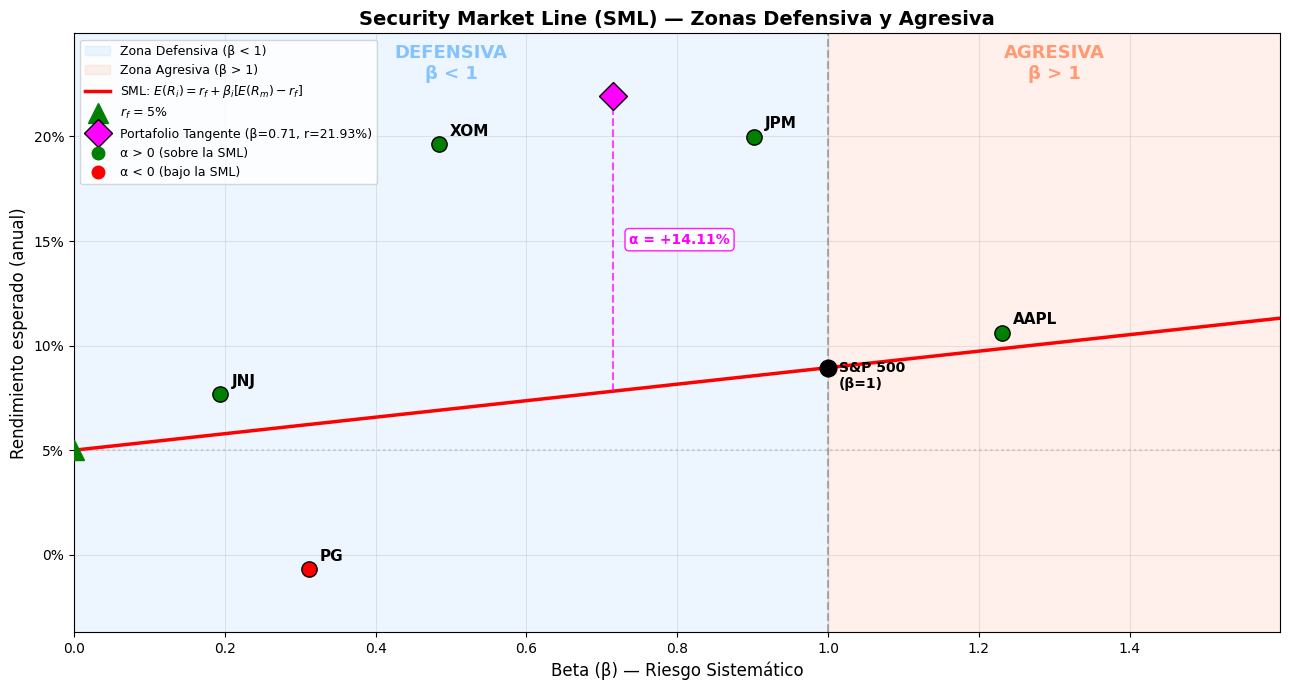

In [16]:
# ─── Beta y rendimiento del portafolio tangente ───
beta_portafolio = sum(w_sharpe[t] * betas[t] for t in tickers)
ret_capm_portafolio = rf_anual + beta_portafolio * (ret_mercado_anual - rf_anual)
alpha_portafolio = ret_sharpe - ret_capm_portafolio

print("══════ PORTAFOLIO TANGENTE EN EL CAPM ══════\n")
print(f"  β portafolio:     {beta_portafolio:.4f}")
print(f"  E(Rp) real:       {ret_sharpe:.2%}")
print(f"  E(Rp) CAPM:       {ret_capm_portafolio:.2%}")
print(f"  Alpha (α):        {alpha_portafolio:+.2%}")

# ─── Gráfico de la SML con zonas defensiva / agresiva ───
fig, ax = plt.subplots(figsize=(13, 7))

# Rango de betas para la línea
beta_max = max(max(betas.values()), beta_portafolio) * 1.3
beta_rango = np.linspace(0, beta_max, 100)
sml = rf_anual + beta_rango * (ret_mercado_anual - rf_anual)

# Determinar límites del eje Y para las áreas sombreadas
y_min = min(min(ret_real_anual.values()), rf_anual) - 0.03
y_max = max(max(ret_real_anual.values()), ret_sharpe) + 0.03

# Áreas: Defensiva (β < 1) y Agresiva (β > 1)
ax.axvspan(0, 1.0, alpha=0.08, color="dodgerblue",
           label="Zona Defensiva (β < 1)")
ax.axvspan(1.0, beta_max, alpha=0.08, color="orangered",
           label="Zona Agresiva (β > 1)")

# Etiquetas de zona
ax.text(0.5, y_max - 0.005, "DEFENSIVA\nβ < 1", ha="center", va="top",
        fontsize=13, fontweight="bold", color="dodgerblue", alpha=0.5)
ax.text(min(1.0 + (beta_max - 1.0) / 2, beta_max - 0.1), y_max - 0.005,
        "AGRESIVA\nβ > 1", ha="center", va="top",
        fontsize=13, fontweight="bold", color="orangered", alpha=0.5)

# SML
ax.plot(beta_rango, sml, "r-", linewidth=2.5, label="SML: $E(R_i) = r_f + β_i [E(R_m) - r_f]$")

# Línea divisoria β = 1
ax.axvline(x=1.0, color="gray", linestyle="--", linewidth=1.5, alpha=0.6)

# Activos individuales
for t in tickers:
    color = "green" if tabla_capm.loc[t, "Alpha (α)"] > 0 else "red"
    ax.plot(betas[t], ret_real_anual[t], "o", color=color, markersize=11,
            markeredgecolor="black", zorder=5)
    ax.annotate(t, (betas[t], ret_real_anual[t]),
                textcoords="offset points", xytext=(8, 6), fontsize=11, fontweight="bold")

# Mercado
ax.plot(1.0, ret_mercado_anual, "ko", markersize=12, zorder=5)
ax.annotate("S&P 500\n(β=1)", (1.0, ret_mercado_anual),
            textcoords="offset points", xytext=(8, -15), fontsize=10, fontweight="bold")

# Activo libre de riesgo
ax.plot(0, rf_anual, "g^", markersize=14, zorder=5, label=f"$r_f$ = {rf_anual:.0%}")

# Portafolio tangente
ax.plot(beta_portafolio, ret_sharpe, "D", color="magenta", markersize=14,
        markeredgecolor="black", zorder=6,
        label=f"Portafolio Tangente (β={beta_portafolio:.2f}, r={ret_sharpe:.2%})")

# Línea vertical del alpha del portafolio
ax.plot([beta_portafolio, beta_portafolio],
        [ret_capm_portafolio, ret_sharpe],
        "--", color="magenta", linewidth=1.5, alpha=0.7)
ax.annotate(f"α = {alpha_portafolio:+.2%}",
            xy=(beta_portafolio, (ret_sharpe + ret_capm_portafolio) / 2),
            textcoords="offset points", xytext=(12, 0), fontsize=10,
            color="magenta", fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="magenta", alpha=0.9))

# Leyenda para activos sobre/bajo la SML
ax.plot([], [], "o", color="green", markersize=9, label="α > 0 (sobre la SML)")
ax.plot([], [], "o", color="red", markersize=9, label="α < 0 (bajo la SML)")

ax.set_xlabel("Beta (β) — Riesgo Sistemático", fontsize=12)
ax.set_ylabel("Rendimiento esperado (anual)", fontsize=12)
ax.set_title("Security Market Line (SML) — Zonas Defensiva y Agresiva", fontsize=14, fontweight="bold")
ax.legend(loc="upper left", fontsize=9, frameon=True)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.axhline(y=rf_anual, color="gray", linestyle=":", alpha=0.3)
ax.grid(True, alpha=0.3)
ax.set_xlim(left=0, right=beta_max)
ax.set_ylim(bottom=y_min, top=y_max)
plt.tight_layout()
plt.show()

## Resumen

| Concepto | Descripción |
|:---|:---|
| **Frontera Eficiente** | Conjunto de portafolios óptimos (máx. rendimiento para cada nivel de riesgo) |
| **Portafolio Mín. Varianza** | El punto más a la izquierda de la frontera — menor riesgo posible |
| **Portafolio Tangente** | Punto donde la CML toca la frontera — máximo Sharpe ratio |
| **CML** | Recta desde $r_f$ pasando por el tangente — mejores combinaciones riesgo-rendimiento |
| **$w > 100\%$** | Apalancamiento: el inversor pide prestado a $r_f$ para invertir más en el tangente |
| **SML** | Recta que relaciona el rendimiento esperado con el riesgo sistemático ($\beta$) según el CAPM |
| **Beta ($\beta$)** | Sensibilidad de un activo al riesgo de mercado: $\beta < 1$ defensivo, $\beta > 1$ agresivo |
| **Alpha de Jensen ($\alpha$)** | Diferencia entre el rendimiento real y el predicho por el CAPM; $\alpha > 0$ indica desempeño superior |

### Security Market Line (SML)

1. **La mayoría de los activos se ubican por encima de la SML** (JNJ, XOM, JPM, AAPL), lo que indica un alpha positivo — rendimiento histórico superior al que predice el CAPM para su nivel de beta.
2. **PG es el único activo por debajo de la SML** ($\alpha < 0$), sugiriendo un desempeño inferior al esperado por su riesgo sistemático.
3. **XOM y JPM destacan con los alphas más altos** (+12.72% y +11.42%), siendo los activos que más valor agregaron por encima de lo que el mercado compensaría.
4. **El portafolio tangente tiene $\beta = 0.71$** (zona defensiva), pero genera un rendimiento de 21.93% — muy por encima del 7.82% que predice el CAPM, con un alpha de **+14.11%**.
5. **Todos los activos excepto AAPL son defensivos** ($\beta < 1$): se mueven menos que el mercado, lo que implica menor exposición al riesgo sistemático.
6. La SML confirma que **la diversificación del portafolio tangente es eficiente**: concentra peso en JPM y XOM (los de mayor alpha) y evita PG (alpha negativo), logrando un rendimiento ajustado por riesgo excepcional.

---

## Taller: Modelo CAPM, Frontera Eficiente y Línea del Mercado

**Instrucciones generales:**  
Seleccione **5 acciones diferentes** a las utilizadas en este cuaderno (pueden ser de cualquier bolsa accesible vía Yahoo Finance) y un **índice de referencia** (benchmark). Utilice datos históricos de al menos **3 años**. Asuma una tasa libre de riesgo $r_f$ de su elección (justifíquela brevemente). Desarrolle cada punto en celdas separadas con código y explicaciones en Markdown.

---

### Parte 1 — Datos y rendimientos (10 pts)

1. Descargue los precios de cierre diarios de sus 5 acciones y del benchmark usando `yfinance`.
2. Calcule los **rendimientos logarítmicos diarios**.
3. Presente una tabla resumen con: número de observaciones, rendimiento medio diario, desviación estándar diaria y rendimiento anualizado de cada activo.
4. Justifique brevemente por qué eligió esas acciones (sector, diversificación, etc.).

---

### Parte 2 — Frontera Eficiente 

5. Estime el **vector de rendimientos esperados** y la **matriz de covarianza** anualizados utilizando `PyPortfolioOpt`.
6. Encuentre el **portafolio de mínima varianza global**. Reporte sus pesos, rendimiento y volatilidad.
7. Encuentre el **portafolio tangente (máximo Sharpe)**. Reporte sus pesos, rendimiento, volatilidad y ratio de Sharpe.
8. Construya una **tabla comparativa** de los pesos de ambos portafolios e incluya un gráfico de barras.
9. Grafique la **frontera eficiente** junto con:
   - Los activos individuales
   - El portafolio de mínima varianza
   - El portafolio tangente
10. **Pregunta de análisis:** ¿Qué diferencias observa en la composición de ambos portafolios? ¿A qué se deben?

---

### Parte 3 — Línea del Mercado de Capitales (CML)

11. Trace la **CML** en el mismo gráfico de la frontera eficiente. Identifique el punto de tangencia.
12. Construya una **tabla de combinaciones** entre el activo libre de riesgo y el portafolio tangente, variando $w$ de 0% a 150% (en incrementos de 5%).
13. Calcule para cada combinación: $E(R_c)$, $\sigma_c$ y el ratio de Sharpe.
14. Encuentre la **combinación sobre la CML** que tiene la misma volatilidad que su portafolio de mínima varianza. Compare sus rendimientos.
15. Grafique el **desplazamiento de la frontera**: muestre cómo la CML domina a la frontera eficiente original y destaque la ganancia en rendimiento a igual riesgo.
16. **Pregunta de análisis:** ¿Por qué la CML siempre está por encima (o sobre) la frontera eficiente? ¿Qué ventaja tiene incluir el activo libre de riesgo?

---

### Parte 4 — Security Market Line (SML) y CAPM 

17. Calcule el **beta ($\beta$)** de cada una de sus 5 acciones respecto al benchmark.
18. Presente una **tabla** con: $\beta_i$, rendimiento real anualizado $E(R_i)$, rendimiento teórico CAPM $E(R_i)^{CAPM}$ y el **Alpha de Jensen** ($\alpha_i$).
19. Calcule el **beta del portafolio tangente** como promedio ponderado de los betas individuales.
20. Grafique la **SML** e incluya:
    - Cada activo individual (coloreado según su alpha: verde si $\alpha > 0$, rojo si $\alpha < 0$)
    - El punto del mercado (benchmark)
    - El punto del portafolio tangente con su alpha
    - Las **zonas defensiva** ($\beta < 1$) y **agresiva** ($\beta > 1$) sombreadas
21. **Preguntas de análisis:**
    - ¿Cuáles activos tienen alpha positivo y cuáles negativo? ¿Qué significa esto en términos de desempeño?
    - ¿Su portafolio tangente es defensivo o agresivo? ¿Por qué?
    - ¿Alguno de sus activos tiene un beta cercano a cero? ¿Qué implicaría esto?

---

### Parte 5 — Interpretación integral 

22. Compare la **CML vs la SML**: ¿qué mide cada una? ¿En qué eje se diferencia el riesgo que utilizan?
23. Si un inversionista conservador quisiera un portafolio con volatilidad máxima del 10%, ¿qué combinación de $r_f$ y portafolio tangente le recomendaría? Calcule los pesos exactos.
24. Si un inversionista agresivo está dispuesto a apalancarse hasta $w = 130\%$, ¿cuál sería su rendimiento y riesgo esperado?
25. Suponga que la tasa libre de riesgo **sube de su $r_f$ actual a $r_f + 2\%$**. Sin recalcular, razone:
    - ¿Cómo se movería la CML?
    - ¿Cambiaría el portafolio tangente? ¿Por qué?
    - ¿Qué pasaría con los alphas de los activos en la SML?
26. Redacte unas **conclusiones generales** (mínimo 5 líneas) que integren sus hallazgos de la frontera eficiente, la CML y la SML.
